In [1]:
pip install pandas_datareader

Note: you may need to restart the kernel to use updated packages.


In [28]:
import pandas_datareader.data as web
import pandas as pd

# Define variables and data source
start_date = "1970-01-01"
end_date = "2019-12-31"
fred_series = {
    "UNRATE": "Unemployment Rate",
    "CPIAUCSL": "Inflation Rate (CPI)",
    "FEDFUNDS": "Federal Funds Rate",
}

# Fetch data from FRED
data = web.DataReader(list(fred_series.keys()), "fred", start_date, end_date)

# Check if data covers full range
print("Raw Data Range:", data.index.min(), "to", data.index.max())

# Rename columns for clarity
data = data.rename(columns={"UNRATE": "Unemployment Rate", "FEDFUNDS": "Federal Funds Rate"})

# Resample to quarterly frequency first
data = data.resample("Q").mean()

# Convert CPI to quarterly inflation rate (percentage change)
data["Inflation Rate"] = data["CPIAUCSL"].pct_change() * 100

# Drop the original CPI column
data = data.drop(columns=["CPIAUCSL"])

# Drop missing values
data = data.dropna()

# Force datetime index to quarterly
data.index = pd.to_datetime(data.index)
data = data.asfreq("Q")

# Verify the fixed data range
print("Processed Data Range:", data.index.min(), "to", data.index.max())

# Display first and last rows
print(data.head(), "\n", data.tail())

# Save to CSV
data.to_csv("us_economy_VAR_data.csv")


Raw Data Range: 1970-01-01 00:00:00 to 2019-12-01 00:00:00
Processed Data Range: 1970-06-30 00:00:00 to 2019-12-31 00:00:00
            Unemployment Rate  Federal Funds Rate  Inflation Rate
DATE                                                             
1970-06-30           4.766667            7.886667        1.399825
1970-09-30           5.166667            6.706667        1.035375
1970-12-31           5.833333            5.566667        1.451751
1971-03-31           5.933333            3.856667        0.841751
1971-06-30           5.900000            4.566667        0.918197 
             Unemployment Rate  Federal Funds Rate  Inflation Rate
DATE                                                             
2018-12-31           3.833333            2.220000        0.407121
2019-03-31           3.866667            2.403333        0.266972
2019-06-30           3.633333            2.396667        0.734717
2019-09-30           3.600000            2.190000        0.329876
2019-12-31      

/var/folders/c7/gjfq1y494ngg8_kz3krcbhcm0000gn/T/ipykernel_3031/759182005.py:23: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  data = data.resample("Q").mean()
/var/folders/c7/gjfq1y494ngg8_kz3krcbhcm0000gn/T/ipykernel_3031/759182005.py:36: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  data = data.asfreq("Q")


In [30]:
from statsmodels.tsa.stattools import adfuller
import numpy as np

def check_stationarity(series):
    result = adfuller(series)
    print(f"ADF Statistic for {series.name}: {result[0]}")
    print(f"p-value: {result[1]}")
    if result[1] < 0.05:
        print("The series is stationary.\n")
    else:
        print("The series is non-stationary. Consider differencing.\n")

# Check for stationarity
for col in data.columns:
    check_stationarity(data[col])

# Difference non-stationary series
data_diff = data.diff().dropna()  # First difference


ADF Statistic for Unemployment Rate: -2.806321624931538
p-value: 0.0573764274358931
The series is non-stationary. Consider differencing.

ADF Statistic for Federal Funds Rate: -1.6188769281333322
p-value: 0.4733181305240695
The series is non-stationary. Consider differencing.

ADF Statistic for Inflation Rate: -2.4712058118518665
p-value: 0.1226383561887428
The series is non-stationary. Consider differencing.



In [32]:
from statsmodels.tsa.api import VAR

# Select optimal lag order
model = VAR(data_diff)
lag_order = model.select_order(maxlags=8)
print(lag_order.summary())


 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -3.744      -3.693     0.02366      -3.723
1      -4.393      -4.188     0.01236      -4.310
2      -4.603     -4.244*     0.01003     -4.457*
3      -4.569      -4.056     0.01038      -4.361
4      -4.622      -3.955    0.009841      -4.352
5      -4.682      -3.862    0.009273      -4.350
6      -4.651      -3.677    0.009571      -4.256
7      -4.626      -3.498    0.009823      -4.169
8     -4.690*      -3.408   0.009230*      -4.171
-------------------------------------------------


In [34]:
# Fit the VAR model
optimal_lag = lag_order.aic  # Use the optimal AIC lag
var_model = model.fit(optimal_lag)
print(var_model.summary())


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 19, Mar, 2025
Time:                     17:24:05
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -3.40814
Nobs:                     190.000    HQIC:                  -4.17065
Log likelihood:          -288.259    FPE:                 0.00923039
AIC:                     -4.68986    Det(Omega_mle):      0.00637038
--------------------------------------------------------------------
Results for equation Unemployment Rate
                           coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------------
const                         0.001816         0.017228            0.105           0.916
L1.Unemployment Rate          0.617612         0.079992            7.721           0.000
L1.Federal Funds

In [36]:
import statsmodels.api as sm
import pandas as pd

# Apply the Ljung-Box test to each residual series separately
for col in var_model.resid.columns:
    print(f"\nLjung-Box test results for residuals of {col}:")
    lb_test = sm.stats.acorr_ljungbox(var_model.resid[col], lags=[10], return_df=True)
    print(lb_test)




Ljung-Box test results for residuals of Unemployment Rate:
     lb_stat  lb_pvalue
10  9.617961   0.474625

Ljung-Box test results for residuals of Federal Funds Rate:
     lb_stat  lb_pvalue
10  1.023826   0.999808

Ljung-Box test results for residuals of Inflation Rate:
     lb_stat  lb_pvalue
10  4.055294   0.944818


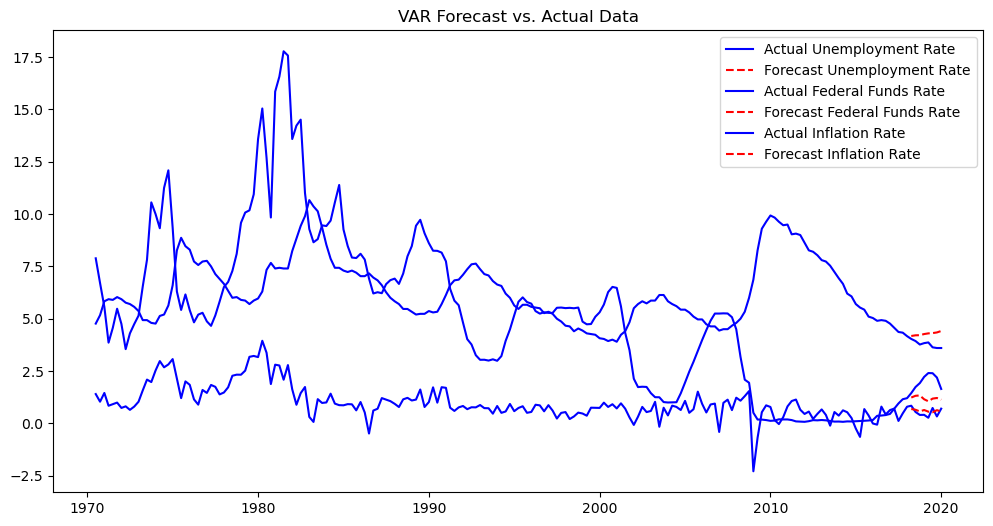

In [38]:
train_data = data_diff[:-8]  # Training data
test_data = data_diff[-8:]   # Test data

# Refit VAR model on training data
var_train = VAR(train_data).fit(optimal_lag)

# Forecast next 8 quarters
forecast_input = train_data.values[-optimal_lag:]
forecast = var_train.forecast(forecast_input, steps=8)

# Convert forecast to DataFrame
forecast_df = pd.DataFrame(forecast, index=test_data.index, columns=data_diff.columns)

# Reverse differencing
forecast_df = data.iloc[-9, :] + forecast_df.cumsum()

# Compare forecasts with actual test data
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for col in data.columns:
    plt.plot(data.index, data[col], label=f"Actual {col}", color='blue')
    plt.plot(forecast_df.index, forecast_df[col], label=f"Forecast {col}", linestyle="dashed", color='red')
plt.legend()
plt.title("VAR Forecast vs. Actual Data")
plt.show()


In [40]:
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

for col in test_data.columns:
    mape = mean_absolute_percentage_error(test_data[col], forecast_df[col])
    rmse = np.sqrt(mean_squared_error(test_data[col], forecast_df[col]))
    print(f"{col} - MAPE: {mape:.2f}, RMSE: {rmse:.2f}")


Unemployment Rate - MAPE: 2484588948486435.50, RMSE: 4.35
Federal Funds Rate - MAPE: 26.21, RMSE: 1.18
Inflation Rate - MAPE: 18.72, RMSE: 0.69


In [42]:
from statsmodels.tsa.stattools import grangercausalitytests

for col in data.columns:
    test = grangercausalitytests(data_diff[[col, "Federal Funds Rate"]], maxlag=optimal_lag, verbose=True)



Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.5840  , p=0.2097  , df_denom=194, df_num=1
ssr based chi2 test:   chi2=1.6085  , p=0.2047  , df=1
likelihood ratio test: chi2=1.6020  , p=0.2056  , df=1
parameter F test:         F=1.5840  , p=0.2097  , df_denom=194, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=5.2641  , p=0.0060  , df_denom=191, df_num=2
ssr based chi2 test:   chi2=10.8037 , p=0.0045  , df=2
likelihood ratio test: chi2=10.5165 , p=0.0052  , df=2
parameter F test:         F=5.2641  , p=0.0060  , df_denom=191, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=3.6053  , p=0.0145  , df_denom=188, df_num=3
ssr based chi2 test:   chi2=11.2187 , p=0.0106  , df=3
likelihood ratio test: chi2=10.9078 , p=0.0122  , df=3
parameter F test:         F=3.6053  , p=0.0145  , df_denom=188, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=3.1911  , p=0.0146  

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


##  When the U.S. economy is experiencing high inflation and high unemployment simultaneously—a situation known as stagflation—the Federal Reserve faces a difficult policy trade-off. Typically, the Fed uses monetary policy tools to either combat inflation (by tightening policy) or reduce unemployment (by easing policy), but addressing both at the same time requires a balanced approach.

Federal Reserve’s Potential Actions:

Monetary Policy Adjustments:
The Fed can adjust interest rates strategically. If inflation is the dominant concern, it may continue raising interest rates to curb excessive price increases. However, if unemployment is also rising sharply, it may opt for a more gradual rate hike to avoid further slowing the economy.
Given the dual challenge, the Fed might pause rate hikes temporarily to assess how previous increases are affecting inflation and labor markets.

Liquidity and Credit Market Support:
The Fed can use open market operations to ensure financial stability. If credit conditions tighten excessively due to higher interest rates, it may inject liquidity selectively into markets to keep businesses afloat while still controlling inflation.

Inflation Targeting with Supply-Side Support:
While interest rate hikes reduce demand-driven inflation, some price increases come from supply chain disruptions or external shocks (e.g., oil price spikes). The Fed might coordinate with fiscal policymakers to encourage supply-side improvements, such as investment in energy production or easing trade restrictions.

Forward Guidance and Market Stability:
Clear communication and guidance are crucial. The Fed can signal to markets that while controlling inflation remains a priority, it is also mindful of economic growth and employment trends. This can anchor inflation expectations while preventing panic in labor markets.

Balancing Inflation and Employment:
If inflation remains stubbornly high, the Fed will likely prioritize inflation control even if it means a short-term rise in unemployment. However, if unemployment surges too quickly, the Fed might adjust its approach to avoid a deep recession.
Fiscal policy (government spending and taxation) could also play a complementary role in addressing unemployment through targeted 
stimulus without worsening inflation.

Conclusion:
The Federal Reserve’s best course of action is likely a measured tightening of monetary policy, coupled with flexibility in responding to labor market conditions. A data-driven approach, where the Fed monitors inflation trends, labor market health, and global economic conditions, will be critical in ensuring a balanced recovery.







